# 00 - EDA: Criteo Uplift Dataset

Experiment audit before any CATE model is fit. Dataset: Criteo Uplift ([Diemert et al., 2018](https://ailab.criteo.com/criteo-uplift-prediction-dataset/)) - 13.98M rows, 12 anonymized features `f0..f11` (random projections, no domain interpretation), randomized ad offer `treatment` (~85% treated / 15% control by design), binary `conversion` (~0.2% control baseline, ATE ~+0.08 pp). A second column `exposure` (actual ad view) gives an instrumental-variable structure used in notebook 04.

Target quantity throughout the project: $\tau(x) = \mathbb{E}[\,Y(1) - Y(0)\,\mid\,X = x\,]$.

Checks: structure and basic statistics, treatment/control balance, naive difference-in-means ATE, per-arm feature distributions, propensity constancy, overlap, outcome- and propensity-model feature importance, SHAP on a hand-built T-Learner for HTE driver candidates.

Background: [RESEARCH.md](RESEARCH.md). Evaluation metrics: [METRICS.md](METRICS.md).

## 0. Imports and global settings

`SEED=42` is fixed across the whole project so notebook-to-notebook comparisons are consistent. EDA runs on a 500K-row subsample; at a ~0.2-0.3% conversion rate and an 85/15 split the control arm holds only a few hundred positives, so every rare-event statistic below carries substantial sampling error.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from criteo_data import fetch_criteo
from lightgbm import LGBMClassifier, LGBMRegressor
import shap
import warnings

warnings.filterwarnings('ignore')
shap.initjs()

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')

SEED = 42
np.random.seed(SEED)

# Set to None to use the full ~14M row dataset
SAMPLE_SIZE = 500_000

## 1. Load the dataset

`fetch_criteo` (local `criteo_data` module; byte-identical Hugging Face mirror of the sklift file) returns a `Bunch`: `data` (features `f0..f11`), `target` (`conversion`), `treatment` (the randomized offer). `exposure` is not in `data`; it is reached via `treatment_col='exposure'` or `'all'` (notebook 04). The download is ~300 MB and cached locally after the first run.

In [2]:
print('Loading Criteo dataset (conversion target)...')
dataset = fetch_criteo(target_col='conversion')

X_full = dataset.data
y_full = dataset.target
treat_full = dataset.treatment

print(f'Full dataset : {X_full.shape[0]:>12,} rows  |  {X_full.shape[1]} features')
print(f'Features     : {list(X_full.columns)}')
print(f'Treatment col: {treat_full.name}')
print(f'Target col   : {y_full.name}')

# Optional: extract exposure if present in the feature matrix
if 'exposure' in X_full.columns:
    exposure_full = X_full['exposure']
    X_full = X_full.drop(columns=['exposure'])
    print('Exposure column extracted separately.')
else:
    exposure_full = None
    print('No exposure column found in features (normal for sklift >= 0.5).')

Loading Criteo dataset (conversion target)...


Full dataset :   13,979,592 rows  |  12 features
Features     : ['f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10', 'f11']
Treatment col: treatment
Target col   : conversion
No exposure column found in features (normal for sklift >= 0.5).


### Subsample

Simple random 500K-row subsample. Assignment is randomized per row, so uniform sampling preserves the ~85/15 treatment share in expectation; no stratification needed at this step.

In [3]:
if SAMPLE_SIZE and SAMPLE_SIZE < len(X_full):
    idx = np.random.choice(len(X_full), size=SAMPLE_SIZE, replace=False)
    X = X_full.iloc[idx].reset_index(drop=True)
    y = y_full.iloc[idx].reset_index(drop=True)
    treatment = treat_full.iloc[idx].reset_index(drop=True)
    if exposure_full is not None:
        exposure = exposure_full.iloc[idx].reset_index(drop=True)
    print(f'Using sample of {SAMPLE_SIZE:,} rows')
else:
    X, y, treatment = X_full.copy(), y_full.copy(), treat_full.copy()
    exposure = exposure_full
    print('Using full dataset')

print(f'\nX shape      : {X.shape}')
print(f'y dtype      : {y.dtype}  |  unique values: {sorted(y.unique())}')
print(f'treatment    : {sorted(treatment.unique())}')

Using sample of 500,000 rows

X shape      : (500000, 12)
y dtype      : Int8  |  unique values: [0, 1]
treatment    : [0, 1]


## 2. Basic statistics

Missing-value check: Criteo has no NaNs in features, target, or treatment.

In [4]:
print('=== Missing values ===')
print(X.isnull().sum().to_string())
print(f'\ny nulls     : {y.isnull().sum()}')
print(f'treatment nulls: {treatment.isnull().sum()}')

=== Missing values ===
f0     0
f1     0
f2     0
f3     0
f4     0
f5     0
f6     0
f7     0
f8     0
f9     0
f10    0
f11    0

y nulls     : 0
treatment nulls: 0


### Feature summary

Features are random projections of the original signals: roughly centered, similar scales. Downstream models here are tree-based and scale-invariant, so no standardization is applied.

In [5]:
X.describe().T.style.format('{:.4f}').background_gradient(cmap='Blues', axis=1)

,count,mean,std,min,25%,50%,75%,max
f0,500000.0000,19.6250,5.3768,12.6164,12.6164,21.9249,24.4481,26.7453
f1,500000.0000,10.0700,0.1047,10.0597,10.0597,10.0597,10.0597,13.8585
f2,500000.0000,8.4466,0.2992,8.2144,8.2144,8.2144,8.7226,9.0520
f3,500000.0000,4.1797,1.3342,-6.8643,4.6799,4.6799,4.6799,4.6799
f4,500000.0000,10.3391,0.3426,10.2805,10.2805,10.2805,10.2805,19.6679
f5,500000.0000,4.0279,0.4319,-5.8798,4.1155,4.1155,4.1155,4.1155
f6,500000.0000,-4.1625,4.5792,-27.9002,-6.6993,-2.4111,0.2944,0.2944
f7,500000.0000,5.1037,1.2103,4.8338,4.8338,4.8338,4.8338,11.9980
f8,500000.0000,3.9335,0.0567,3.6409,3.9108,3.9719,3.9719,3.9719
f9,500000.0000,16.0282,7.0188,13.1901,13.1901,13.1901,13.1901,72.6572


## 3. Treatment / control balance

Unequal-allocation RCT: ~85% treated / 15% control by design (treatment ratio ~0.85), still randomized independently of $X$. The small control arm is the variance bottleneck for every two-model estimator, and control converters are the scarcest cell of all - the reason every split in this project stratifies on (treatment × conversion).

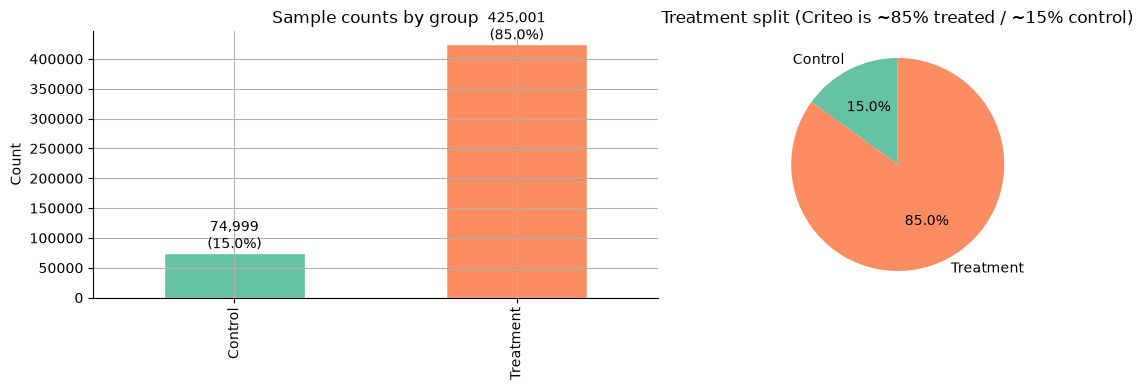

treatment
Control       74999
Treatment    425001
Name: count, dtype: Int64


In [6]:
# sort_index() -> index order is [0->Control, 1->Treatment], so the pie labels
# line up with the colors (value_counts() alone sorts by size and would swap them
# under an 85/15 split).
treat_counts = treatment.value_counts().sort_index().rename({0: 'Control', 1: 'Treatment'})

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

treat_counts.plot.bar(ax=axes[0], color=['#66c2a5', '#fc8d62'], edgecolor='white')
axes[0].set_title('Sample counts by group')
axes[0].set_xlabel('')
axes[0].set_ylabel('Count')
axes[0].bar_label(axes[0].containers[0],
                  labels=[f'{v:,}\n({v/len(treatment):.1%})' for v in treat_counts])

treat_counts.plot.pie(ax=axes[1], autopct='%1.1f%%',
                      colors=['#66c2a5', '#fc8d62'], startangle=90)
axes[1].set_title('Treatment split (Criteo is ~85% treated / ~15% control)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('eda_treatment_balance.png', dpi=150, bbox_inches='tight')
plt.show()
print(treat_counts)

## 4. Conversion rates and the naive ATE

Difference-in-means, $\widehat{\mathrm{ATE}} = \bar Y_{T=1} - \bar Y_{T=0}$, unbiased under randomization. Computed from the raw $(T \times Y)$ cross-table below.

In [7]:
crosstab = pd.crosstab(
    treatment.map({0: 'Control', 1: 'Treatment'}),
    y.map({0: 'No conversion', 1: 'Conversion'}),
    margins=True, margins_name='Total',
)
print('=== (T × Y) cross-table ===')
print(crosstab)

=== (T × Y) cross-table ===
conversion  Conversion  No conversion   Total
treatment                                    
Control            150          74849   74999
Treatment         1382         423619  425001
Total             1532         498468  500000


In [8]:
cr_ctrl  = y[treatment == 0].mean()
cr_treat = y[treatment == 1].mean()
n_ctrl   = (treatment == 0).sum()
n_treat  = (treatment == 1).sum()

print(f'Control   CR : {cr_ctrl:.6f}   ({cr_ctrl*100:.4f} %)   on n={n_ctrl:,}')
print(f'Treatment CR : {cr_treat:.6f}   ({cr_treat*100:.4f} %)   on n={n_treat:,}')

Control   CR : 0.002000   (0.2000 %)   on n=74,999
Treatment CR : 0.003252   (0.3252 %)   on n=425,001


### ATE and standard error

$$
\mathrm{SE}(\widehat{\mathrm{ATE}}) \;=\; \sqrt{\frac{p_1(1-p_1)}{n_1} + \frac{p_0(1-p_0)}{n_0}}
$$

95% Wald CI: $\widehat{\mathrm{ATE}} \pm 1.96 \cdot \mathrm{SE}$.

In [9]:
ate     = cr_treat - cr_ctrl
ate_se  = np.sqrt(cr_treat*(1-cr_treat)/n_treat + cr_ctrl*(1-cr_ctrl)/n_ctrl)
ate_lb  = ate - 1.96 * ate_se
ate_ub  = ate + 1.96 * ate_se
ate_rel = ate / cr_ctrl

print(f'ATE (absolute) : {ate:+.6f}  ({ate*100:+.4f} pp)')
print(f'SE (asymptotic): {ate_se:.6f}')
print(f'95% CI         : [{ate_lb:+.6f}, {ate_ub:+.6f}]')
print(f'ATE (relative) : {ate_rel:+.2%} vs. control baseline')
print(f'Excludes zero  : {ate_lb > 0 or ate_ub < 0}')

ATE (absolute) : +0.001252  (+0.1252 pp)
SE (asymptotic): 0.000185
95% CI         : [+0.000889, +0.001614]
ATE (relative) : +62.59% vs. control baseline
Excludes zero  : True


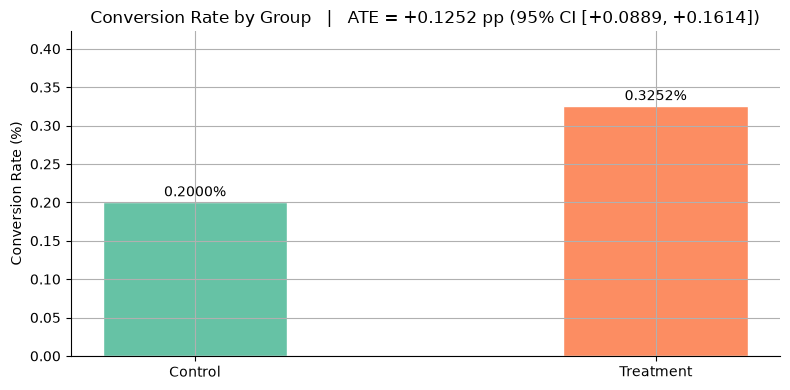

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(['Control', 'Treatment'], [cr_ctrl*100, cr_treat*100],
              color=['#66c2a5', '#fc8d62'], edgecolor='white', width=0.4)
ax.bar_label(bars, labels=[f'{cr_ctrl*100:.4f}%', f'{cr_treat*100:.4f}%'], padding=2)
ax.set_title(f'Conversion Rate by Group   |   ATE = {ate*100:+.4f} pp (95% CI [{ate_lb*100:+.4f}, {ate_ub*100:+.4f}])')
ax.set_ylabel('Conversion Rate (%)')
ax.set_ylim(0, max(cr_treat, cr_ctrl) * 100 * 1.3)
plt.tight_layout()
plt.savefig('eda_conversion_rates.png', dpi=150, bbox_inches='tight')
plt.show()

The measured effect - about **+0.12 pp** on this 500K sample (~+0.08 pp on the full data) - is the entire signal every CATE model in this project tries to localize into per-user effects. Models claiming much larger $\hat\tau(x)$ for many users deserve suspicion.

## 5. Feature distributions: treatment vs. control

Under randomization $X \perp T$ holds in expectation, so per-arm feature distributions should differ only by sampling noise; overlaid KDEs are the cheapest check. Marginal equality does not prove joint independence - a standardized-mean-difference table or permutation test is the formal version.

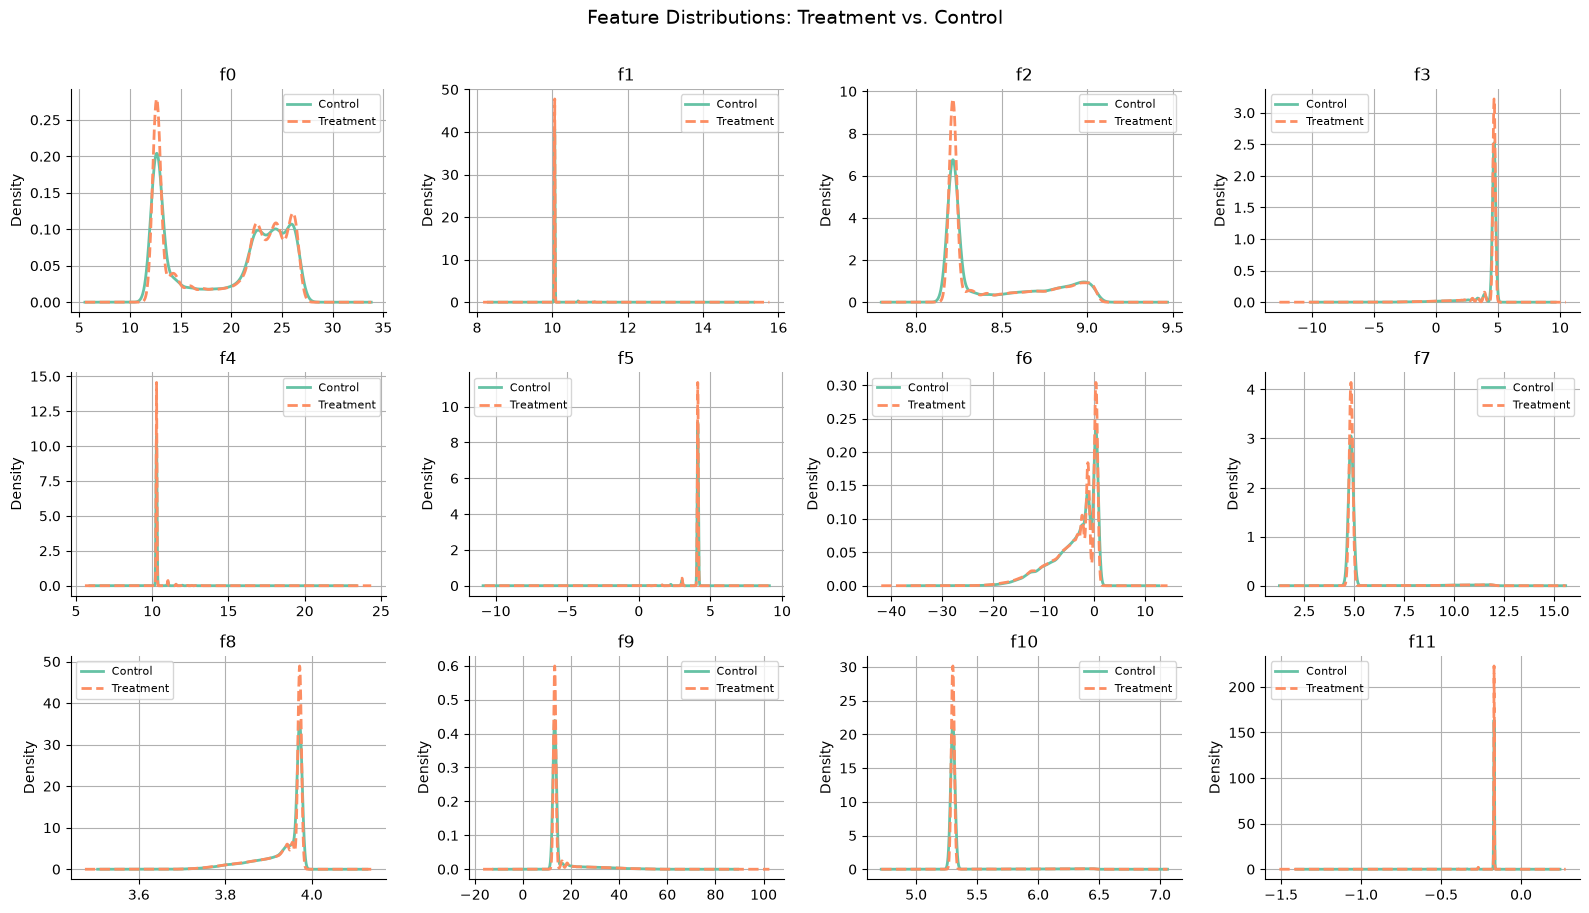

In [11]:
feature_cols = X.columns.tolist()
n_features = len(feature_cols)
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    ax = axes[i]
    X.loc[treatment == 0, col].plot.kde(ax=ax, label='Control', color='#66c2a5', lw=2)
    X.loc[treatment == 1, col].plot.kde(ax=ax, label='Treatment', color='#fc8d62', lw=2, linestyle='--')
    ax.set_title(col)
    ax.set_xlabel('')
    ax.legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Feature Distributions: Treatment vs. Control', y=1.01, fontsize=14)
plt.tight_layout()
plt.savefig('eda_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Feature correlation heatmap

Mild correlation is structural (features are random projections of shared signals). Nothing pathological here - most pairs are below |ρ| < 0.3.

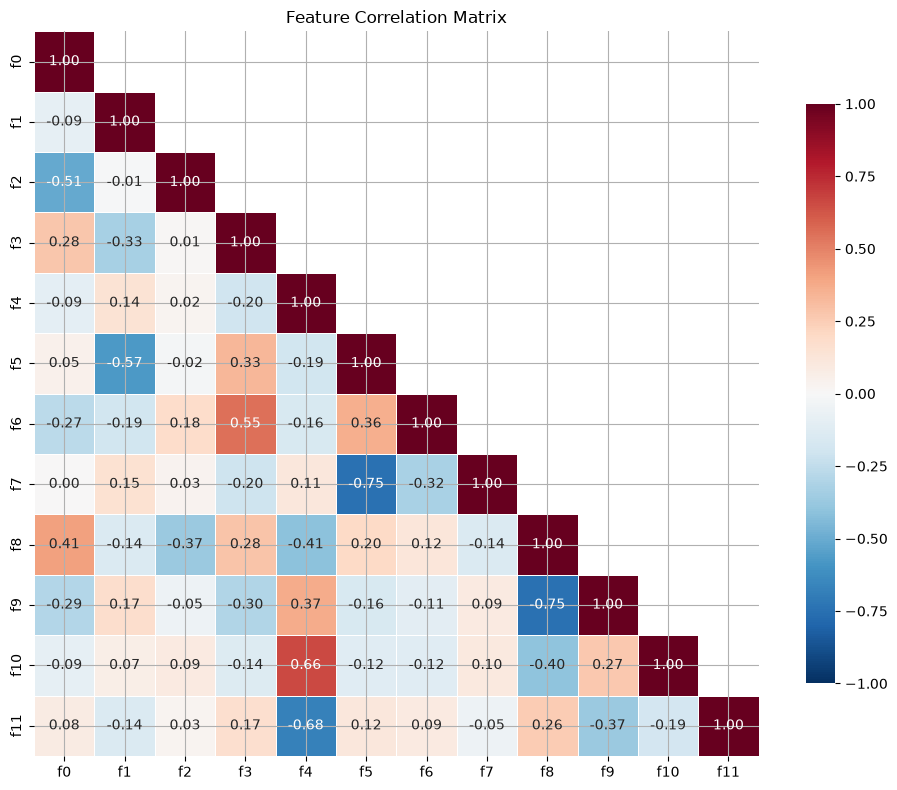

In [12]:
corr = X.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, ax=ax,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Propensity score check (randomization verification)

In this RCT the propensity is constant by design: $e(x) \equiv \Pr(T=1) \approx 0.85$. A propensity model evaluated on held-out (cross-validated) predictions should recover that constant; in-sample predictions would overfit away from it even in a clean RCT. Downstream, estimated propensities are clipped to [0.01, 0.99] - the standard variance fix for inverse-propensity weights.

In [13]:
from sklearn.model_selection import cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.calibration import calibration_curve

propensity_model = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=500, random_state=SEED))
])

propensity_scores = cross_val_predict(
    propensity_model, X, treatment, cv=5, method='predict_proba'
)[:, 1]

print(f'Propensity scores: mean={propensity_scores.mean():.4f}  '
      f'std={propensity_scores.std():.4f}  '
      f'min={propensity_scores.min():.4f}  '
      f'max={propensity_scores.max():.4f}')

# Clip check
clip_frac = ((propensity_scores < 0.1) | (propensity_scores > 0.9)).mean()
print(f'Fraction outside [0.1, 0.9]: {clip_frac:.4%}  (should be ~0 in a clean RCT)')

Propensity scores: mean=0.8500  std=0.0074  min=0.8158  max=0.9304
Fraction outside [0.1, 0.9]: 0.0820%  (should be ~0 in a clean RCT)


### Distribution + calibration

Left: $\hat e(x)$ histograms per arm - both should concentrate near the design ratio ~0.85 (vertical line = empirical $\Pr(T=1)$). Right: calibration curve - points near the diagonal mean the predicted probabilities are honest.

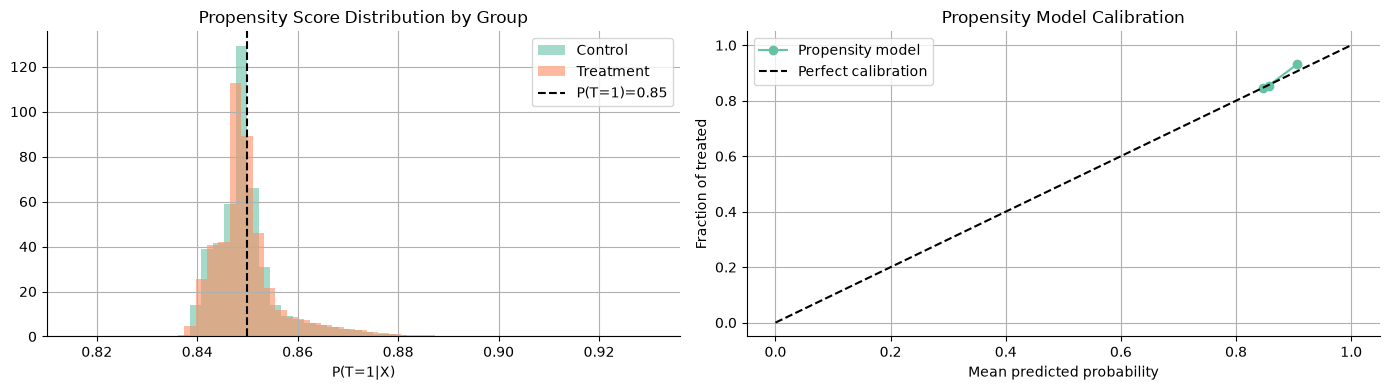

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
e_bar = treatment.mean()   # RCT propensity is (near-)constant; expect ~0.85 on Criteo

# Propensity distribution
axes[0].hist(propensity_scores[treatment == 0], bins=50, alpha=0.6,
             color='#66c2a5', label='Control', density=True)
axes[0].hist(propensity_scores[treatment == 1], bins=50, alpha=0.6,
             color='#fc8d62', label='Treatment', density=True)
axes[0].axvline(e_bar, color='black', linestyle='--', lw=1.5, label=f'P(T=1)={e_bar:.2f}')
axes[0].set_title('Propensity Score Distribution by Group')
axes[0].set_xlabel('P(T=1|X)')
axes[0].legend()

# Calibration curve
frac_pos, mean_pred = calibration_curve(treatment, propensity_scores, n_bins=20)
axes[1].plot(mean_pred, frac_pos, marker='o', label='Propensity model')
axes[1].plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
axes[1].set_title('Propensity Model Calibration')
axes[1].set_xlabel('Mean predicted probability')
axes[1].set_ylabel('Fraction of treated')
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_propensity.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Overlap (common support)

Positivity requires $0 < e(x) < 1$; propensity mass near 0 or 1 (red regions) destabilizes IPW and DR estimators. Here the propensity sits tightly around 0.85, so overlap is excellent. Note the asymmetry: control-arm weights $1/(1-\hat e) \approx 6.7$ are the large ones - another way the small control arm dominates variance.

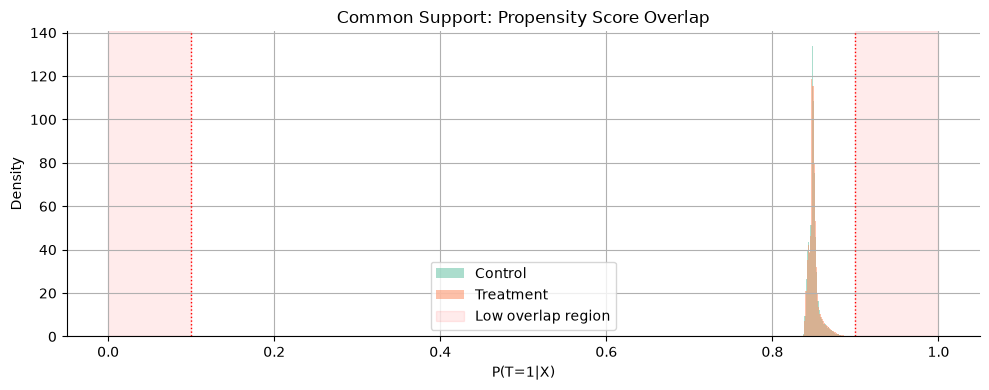

In [15]:
fig, ax = plt.subplots(figsize=(10, 4))

for grp, label, color in [(0, 'Control', '#66c2a5'), (1, 'Treatment', '#fc8d62')]:
    mask = treatment == grp
    ax.hist(propensity_scores[mask], bins=80, alpha=0.55, density=True,
            color=color, label=label)

ax.axvspan(0, 0.1, alpha=0.08, color='red', label='Low overlap region')
ax.axvspan(0.9, 1, alpha=0.08, color='red')
ax.axvline(0.1, color='red', lw=1, linestyle=':')
ax.axvline(0.9, color='red', lw=1, linestyle=':')
ax.set_title('Common Support: Propensity Score Overlap')
ax.set_xlabel('P(T=1|X)')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.savefig('eda_overlap.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Feature importance - outcome model

LightGBM on $(X \to Y)$ ignoring $T$: ranks drivers of the marginal outcome $\mathbb{E}[Y \mid X]$, not of $\tau(x)$. A useful prior for the HTE search only - a feature useless for $\mathbb{E}[Y \mid X]$ can still drive heterogeneity. Importance shown is LightGBM gain.

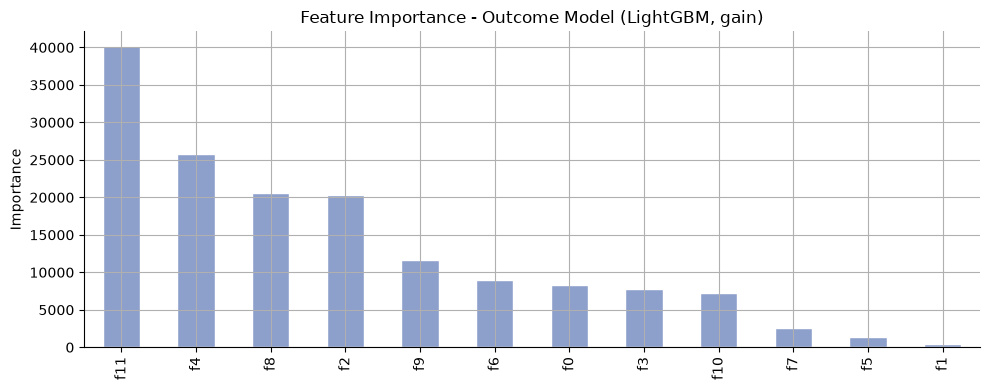

f11    40140.658554
f4     25779.781110
f8     20632.316000
f2     20259.288217
f9     11707.482364
f6      8991.391699
f0      8367.118975
f3      7808.431381
f10     7267.124432
f7      2596.016943
f5      1325.187502
f1       402.639936
Name: importance, dtype: float64


In [16]:
outcome_model = LGBMClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    num_leaves=63, subsample=0.8, colsample_bytree=0.8,
    importance_type='gain',   # sklearn API default is 'split'; we want gain
    random_state=SEED, n_jobs=-1, verbose=-1
)
outcome_model.fit(X, y)

fi_outcome = pd.Series(
    outcome_model.feature_importances_,
    index=X.columns, name='importance'
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
fi_outcome.plot.bar(ax=ax, color='#8da0cb', edgecolor='white')
ax.set_title('Feature Importance - Outcome Model (LightGBM, gain)')
ax.set_ylabel('Importance')
ax.set_xlabel('')
plt.tight_layout()
plt.savefig('eda_feature_importance_outcome.png', dpi=150, bbox_inches='tight')
plt.show()
print(fi_outcome)

## 10. Feature importance - propensity model

Complementary to section 7: with true randomization no feature predicts $T$, so importances should be small and roughly uniform. A single dominant feature would flag treatment leakage into a covariate.

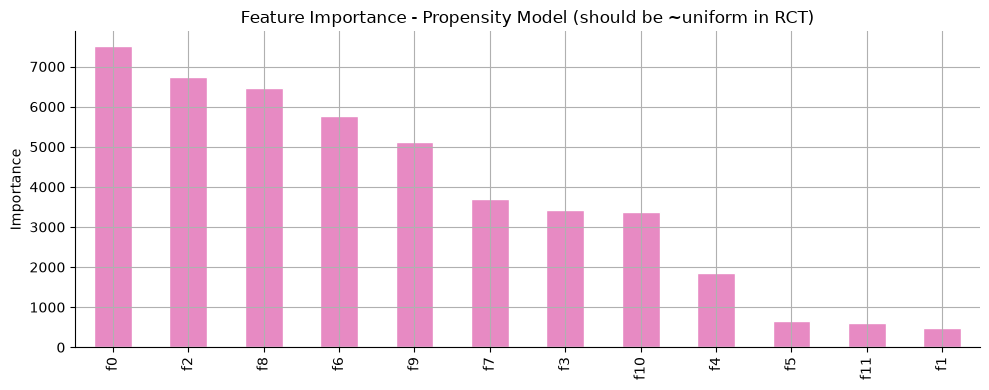

In [17]:
propensity_lgbm = LGBMClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    num_leaves=63, subsample=0.8, colsample_bytree=0.8,
    importance_type='gain',
    random_state=SEED, n_jobs=-1, verbose=-1
)
propensity_lgbm.fit(X, treatment)

fi_propensity = pd.Series(
    propensity_lgbm.feature_importances_,
    index=X.columns, name='importance'
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
fi_propensity.plot.bar(ax=ax, color='#e78ac3', edgecolor='white')
ax.set_title('Feature Importance - Propensity Model (should be ~uniform in RCT)')
ax.set_ylabel('Importance')
plt.tight_layout()
plt.savefig('eda_feature_importance_propensity.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. SHAP analysis - heterogeneous treatment effect drivers

A hand-built T-Learner (two LightGBMs, one per arm) gives $\hat\tau(x) = \hat m_1(x) - \hat m_0(x)$; SHAP is then run on $\hat m_1$. Two caveats: this explains the treated-arm outcome model, not the CATE directly, and `TreeExplainer` works on the log-odds (margin) scale, so the SHAP($\hat m_1$) minus SHAP($\hat m_0$) identity is exact on the margin only. Prior studies commonly report `f8` as the dominant feature here; confirm on your own run.

### Split into the two arms

In [18]:
X_ctrl = X[treatment == 0]
y_ctrl = y[treatment == 0]
X_trt  = X[treatment == 1]
y_trt  = y[treatment == 1]

print(f'Control arm  : n={len(X_ctrl):,}   positives={y_ctrl.sum():>5,}   CR={y_ctrl.mean()*100:.4f}%')
print(f'Treatment arm: n={len(X_trt):,}   positives={y_trt.sum():>5,}   CR={y_trt.mean()*100:.4f}%')

Control arm  : n=74,999   positives=  150   CR=0.2000%
Treatment arm: n=425,001   positives=1,382   CR=0.3252%


### Fit $\hat m_0$ on control rows only

In [19]:
params = dict(n_estimators=300, learning_rate=0.05, max_depth=6,
              num_leaves=63, subsample=0.8, colsample_bytree=0.8,
              random_state=SEED, n_jobs=-1, verbose=-1)

m0 = LGBMClassifier(**params).fit(X_ctrl, y_ctrl)

# Quick sanity check: in-sample predictions should average to control CR
print(f'm0 mean predicted P(Y=1 | T=0): {m0.predict_proba(X_ctrl)[:,1].mean():.6f}  (should match control CR)')

m0 mean predicted P(Y=1 | T=0): 0.002001  (should match control CR)


### Fit $\hat m_1$ on treated rows only

In [20]:
m1 = LGBMClassifier(**params).fit(X_trt, y_trt)

print(f'm1 mean predicted P(Y=1 | T=1): {m1.predict_proba(X_trt)[:,1].mean():.6f}  (should match treatment CR)')

m1 mean predicted P(Y=1 | T=1): 0.003255  (should match treatment CR)


### Compute $\hat\tau(x) = \hat m_1(x) - \hat m_0(x)$ for every row

Mean $\hat\tau$ should sit near the section-4 ATE. Extreme negative values more likely reflect low-density regions of $X$ than genuine sleeping dogs.

In [21]:
p1 = m1.predict_proba(X)[:, 1]
p0 = m0.predict_proba(X)[:, 1]
tau_hat = p1 - p0

print(f'τ̂(X) stats   : mean={tau_hat.mean():.6f}   std={tau_hat.std():.6f}')
print(f'τ̂(X) extremes: min ={tau_hat.min():.6f}   max={tau_hat.max():.6f}')
print(f'τ̂(X) > 0      : {(tau_hat > 0).mean():.2%} of users ("persuadable" candidates)')
print(f'τ̂(X) < 0      : {(tau_hat < 0).mean():.2%} of users ("sleeping dog" candidates)')
print(f'\nCompare ATE from step 4c : {ate:.6f}   |   mean τ̂   : {tau_hat.mean():.6f}')

τ̂(X) stats   : mean=0.001712   std=0.031000
τ̂(X) extremes: min =-0.994474   max=0.998851
τ̂(X) > 0      : 97.34% of users ("persuadable" candidates)
τ̂(X) < 0      : 2.67% of users ("sleeping dog" candidates)

Compare ATE from step 4c : 0.001252   |   mean τ̂   : 0.001712


### $\hat\tau$ distribution

Centered near the ATE with a long positive tail (the targetable mass). Much of the negative mass is estimation noise from a non-honest T-Learner; notebook 02 adds proper CIs.

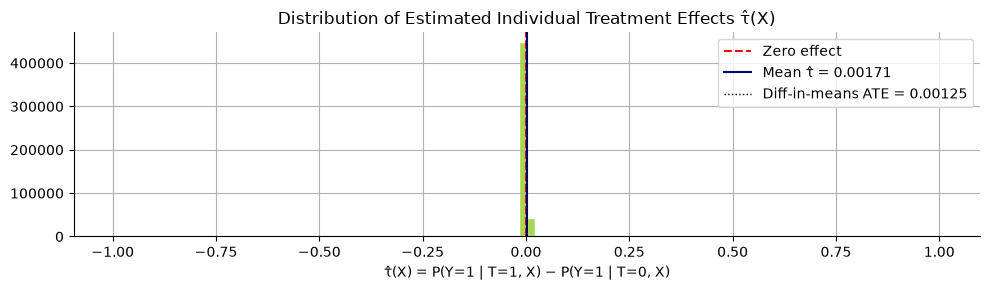

In [22]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.hist(tau_hat, bins=100, color='#a6d854', edgecolor='white')
ax.axvline(0, color='red', lw=1.5, linestyle='--', label='Zero effect')
ax.axvline(tau_hat.mean(), color='navy', lw=1.5, linestyle='-',
           label=f'Mean τ̂ = {tau_hat.mean():.5f}')
ax.axvline(ate, color='black', lw=1.0, linestyle=':',
           label=f'Diff-in-means ATE = {ate:.5f}')
ax.set_title('Distribution of Estimated Individual Treatment Effects τ̂(X)')
ax.set_xlabel('τ̂(X) = P(Y=1 | T=1, X) − P(Y=1 | T=0, X)')
ax.legend()
plt.tight_layout()
plt.savefig('eda_tau_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### SHAP plots

Bar: mean $|\text{SHAP}|$ ranking. Beeswarm: direction (color = feature value, x = contribution to $\hat m_1$). Computed on a 5K subsample for cost. Read the top features as HTE driver candidates, not a proven CATE decomposition.

SHAP values shape: (5000, 12)


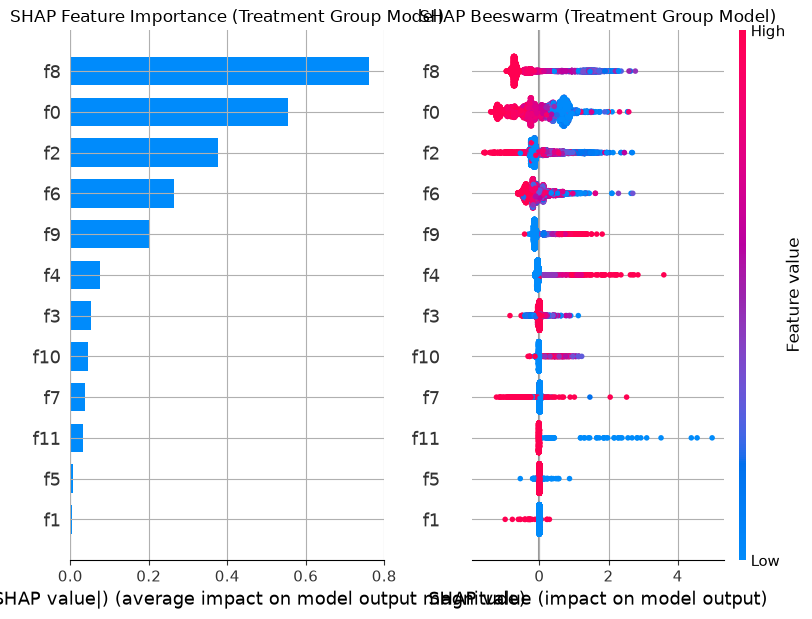

In [23]:
# SHAP on the treatment-group model (m1) to understand what drives HTE
# Use a subsample for speed
shap_sample_size = min(5_000, len(X))
shap_idx = np.random.choice(len(X), size=shap_sample_size, replace=False)
X_shap = X.iloc[shap_idx]

explainer = shap.TreeExplainer(m1)
shap_values = explainer.shap_values(X_shap)

# Older shap returned a list [class0, class1] for binary classifiers; current
# shap (>=0.45) returns a single 2D array for the positive class. Handle both.
if isinstance(shap_values, list):
    sv = shap_values[1]  # class 1 (conversion)
else:
    sv = shap_values

print(f'SHAP values shape: {sv.shape}')

n_feat = X.shape[1]   # 12 on Criteo (f0..f11)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plt.sca(axes[0])
shap.summary_plot(sv, X_shap, plot_type='bar', show=False, max_display=n_feat)
axes[0].set_title('SHAP Feature Importance (Treatment Group Model)')

plt.sca(axes[1])
shap.summary_plot(sv, X_shap, show=False, max_display=n_feat)
axes[1].set_title('SHAP Beeswarm (Treatment Group Model)')

plt.tight_layout()
plt.savefig('eda_shap.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. τ̂(X) by feature decile

Mean $\hat\tau$ per decile of each top-6 feature; a structured trend marks an HTE candidate, flat bars near the ATE mark a non-driver. Hypothesis-level only: $\hat\tau$ comes from a non-honest, non-cross-fit T-Learner. The formal check is the Best Linear Predictor test of Chernozhukov, Demirer, Duflo & Fernández-Val (2018); notebooks 02-03 add honesty, cross-fitting, and CIs.

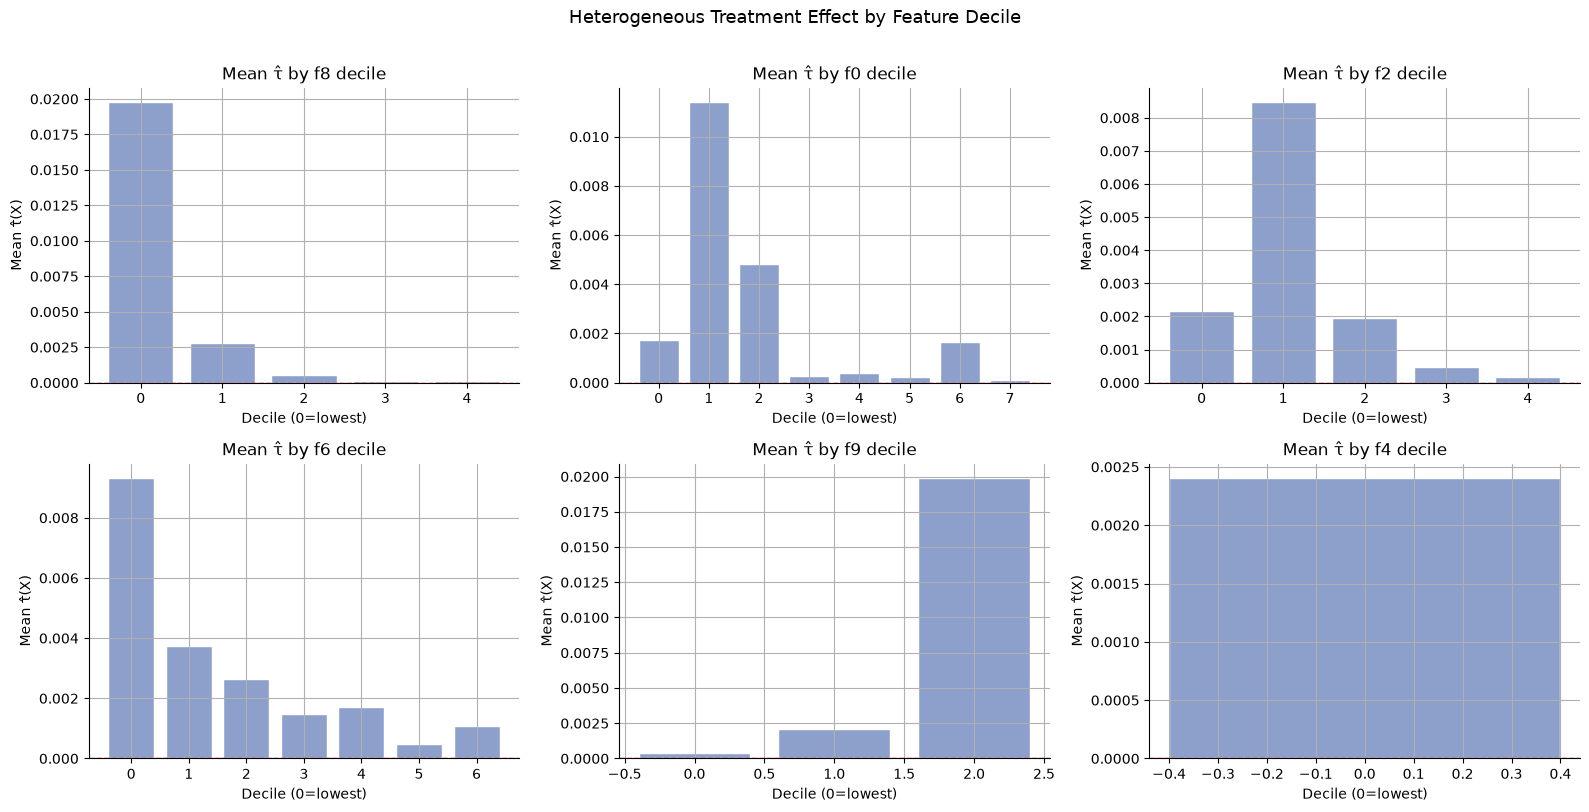

In [24]:
df_shap = X.iloc[shap_idx].copy()
df_shap['tau_hat'] = tau_hat[shap_idx]

# Rank features by SHAP importance
top_features = pd.Series(
    np.abs(sv).mean(axis=0), index=X.columns
).sort_values(ascending=False).index[:6].tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    df_shap[f'{feat}_decile'] = pd.qcut(df_shap[feat], q=10, labels=False, duplicates='drop')
    grp = df_shap.groupby(f'{feat}_decile')['tau_hat'].mean()
    axes[i].bar(grp.index, grp.values, color='#8da0cb', edgecolor='white')
    axes[i].axhline(0, color='red', lw=1, linestyle='--')
    axes[i].set_title(f'Mean τ̂ by {feat} decile')
    axes[i].set_xlabel('Decile (0=lowest)')
    axes[i].set_ylabel('Mean τ̂(X)')

plt.suptitle('Heterogeneous Treatment Effect by Feature Decile', y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig('eda_tau_by_feature.png', dpi=150, bbox_inches='tight')
plt.show()

## Key EDA findings

Numbers in the table are the expected shape from the literature / dataset docs; the authoritative values are the ones printed by the executed cells above.

| Finding | Details | Implication |
|---|---|---|
| **Treatment balance** | ~85% treated / ~15% control (treatment ratio ≈ 0.85) | The small control arm is the variance bottleneck for all two-model estimators |
| **Baseline CR** | Control ≈ 0.22%, Treatment ≈ 0.30% (overall ≈ 0.29%) | Conversions are *rare* - stratified splits are mandatory; large hold-outs essential for stable Qini |
| **ATE** | ≈ +0.08 pp (relative lift ~+35-40%) | All ranking metrics will be noisy; differences smaller than their SEs should not be interpreted as model superiority |
| **Propensity** | $\hat e \approx 0.85$, ~constant, calibrated | Randomization intact, no confounding signal under tested models |
| **Overlap** | Full overlap; propensity mass near 0.85, none near 0 or 1 | Positivity holds → IPW / DR methods are stable |
| **HTE driver candidate** | `f8` expected to top SHAP-on-$\hat m_1$ | Heterogeneity is *plausible* - uplift beyond ATE may be recoverable; a formal BLP-style test on the DR pseudo-outcome (notebook 06) is the honest confirmation |
| **τ̂ distribution** | Centered near ATE with a long positive tail | Most users are flat-effect; the targetable mass is in the tail |

Next: [01_meta_learners.ipynb](01_meta_learners.ipynb) (meta-learners), then tree methods (02), DML (03), advanced models (04), HPO (05), and the final bootstrap-CI leaderboard (06).